# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head()
 # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()
 # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()
# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()
# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())

# cantidad de nulos para usage

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
 
 Dataset USERS:
🔍 Análisis por columna:

city (11.7% nulos): Está en el rango 5-30%, se debe investigar para imputar. Justificación: Es información geográfica valiosa para segmentación por región.
churn_date (88.4% nulos): Más del 80%, pero NO eliminar. Justificación: Los nulos indican clientes activos (no han hecho churn), es información valiosa para el negocio.
Dataset USAGE:
🔍 Análisis por columna:

date (0.1% nulos): Menos del 5%, imputación simple o eliminar filas. Justificación: Son muy pocos casos y las fechas son críticas para análisis temporal.
duration (55.2% nulos): Más del 50%, pero mantener como nulos. Justificación: Solo aplica para llamadas (type='call'), los mensajes no tienen duración.
length (44.7% nulos): Más del 40%, pero mantener como nulos. Justificación: Solo aplica para mensajes (type='text'), las llamadas no tienen longitud de caracteres.
🎯 Acciones Recomendadas:
city: Imputar con "Desconocido" o la ciudad más frecuente
churn_date: Mantener nulos (representan clientes activos)
date: Eliminar las 50 filas con fechas nulas
duration y length: Mantener nulos (son MAR - Missing At Random)




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users[['user_id', 'age']].describe()

 # explorar columnas numéricas de users
sentinel_count = (users['age'] == -999).sum()
print(f"Registros con sentinel -999: {sentinel_count}")
print(f"Porcentaje del total: {sentinel_count/len(users)*100:.2f}%")

edades_validas = users[users['age'] != -999]['age']
print(f"Media de edades válidas: {edades_validas.mean():.1f}")
print(f"Mediana de edades válidas: {edades_validas.median():.1f}")

users[['user_id', 'age']].describe()


Registros con sentinel -999: 55
Porcentaje del total: 1.38%
Media de edades válidas: 48.1
Mediana de edades válidas: 48.0


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`
  
Análisis de la columna user_id:
Según el .describe() 

Rango: Los IDs van de 10,000 a 13,999 (4,000 usuarios únicos)
Distribución: Parece secuencial y bien estructurada
Sin problemas aparentes: No hay valores duplicados ni fuera de rango

- La columna `age`

 Valor mínimo: -999 (¡esto es claramente un valor sentinel!)
Rango válido: De 32 a 79 años para valores reales




In [13]:
usage[['id', 'user_id', 'duration', 'length']].describe() 

# explorar columnas numéricas de usage



,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...no tiene valores duplicados eso esta bien porque nos demuestra que todos los usuarios tienen un registro único.
  
- Las columnas ...están dentro del rango esperado y coinciden con los IDs del dataset users, lo que sugiere una buena integridad referencial.



In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n=== Análisis de la columna '{col}' ===")
    print(f"Valores únicos: {users[col].nunique()}")
    print(f"Valores únicos:")
    print(users[col].value_counts(dropna=False))
    print("-" * 40)


=== Análisis de la columna 'city' ===
Valores únicos: 7
Valores únicos:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
----------------------------------------

=== Análisis de la columna 'plan' ===
Valores únicos: 2
Valores únicos:
Basico     2595
Premium    1405
Name: plan, dtype: int64
----------------------------------------


- La columna `city` ... indica que hay 96 registros sin ciudad lo que puede ser menos del 3 % lo cual no afecta la muestra
- La columna `plan` ... solo hay dos planes basico y premium 

In [15]:
# explorar columna categórica de usage
usage['type'] # completa el código

print("=== ANÁLISIS DE LA COLUMNA 'TYPE' ===")
print(f"Total de registros: {len(usage)}")
print(f"Valores únicos: {usage['type'].nunique()}")
print(f"Valores únicos encontrados: {usage['type'].unique()}")
print("\nDistribución:")
print(usage['type'].value_counts(dropna=False))
print("\nPorcentajes:")
print(usage['type'].value_counts(normalize=True, dropna=False) * 100)


=== ANÁLISIS DE LA COLUMNA 'TYPE' ===
Total de registros: 40000
Valores únicos: 2
Valores únicos encontrados: ['call' 'text']

Distribución:
text    22092
call    17908
Name: type, dtype: int64

Porcentajes:
text    55.23
call    44.77
Name: type, dtype: float64


- La columna `type` ... describe el tipo de contacto que tuvo el usuario texto o llamada siendo 4000 registros 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías? 
-En el data set Users la columna age claramente muestra un sentinel en las edades (-999) reemplazar con la media seria algo conveniente ya que se analizaran las edades
-La columna 'city' tiene 96 registros sin ciudad lo cual representa menos del 3% lo mas honesto seria eliminar estos registros ya que no cuentan con una ciudad 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date']  = pd.to_datetime(users['reg_date'], errors='coerce') 

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nRango de años: {users['reg_date'].dt.year.min()} - {users['reg_date'].dt.year.max()}")


Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Rango de años: 2022 - 2026


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. 

Se puede observar una ausencia de registros en el año 2025 y en 2026 se puede ver como vuelven a tener registros pero muy pocos en comparacion a los años anteriores. 

In [19]:
# Revisar los años presentes en `date` de usage
print("Años en date:")
print(usage['date'].dt.year.value_counts().sort_index())
print(f"\nRango de años: {usage['date'].dt.year.min()} - {usage['date'].dt.year.max()}")

Años en date:
2024.0    39950
Name: date, dtype: int64

Rango de años: 2024.0 - 2024.0


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Se puede notar que en el año 2024 es donde están concentrados los datos. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Los años en 'reg_date' son completamente posibles, sólo habria que investigar La ausencia total de registros en 2025 es definitivamente 
Podría indicar problemas en el sistema de captura de datos, migración de sistemas, o algún evento específico en la empresa ¿Hubo algún cambio en el sistema de registro? ¿Migración de base de datos? ¿Problemas técnicos?

Lo que puedo recomendar es:
Documentar esta anomalía temporal en tu análisis ejecutivo
Preguntar al equipo de negocio sobre el contexto de 2025 y 2026
Considerar hacer el análisis principal con datos 2022-2024 y tratar 2026 por separado

En 'date' al estar la mayoria en 2024 podríamos basar nuestro análisis en esta fecha ya que ser{ia la que nos puede dar informaci{on importante.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar "?" por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en city después del reemplazo:")
print(users['city'].value_counts(dropna=False))

Valores únicos en city después del reemplazo:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


# Verificar cambios
print(users['reg_date'].dt.year.value_counts().sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())


type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` los valores nulos  son estructuralmente esperados (no errores) no deberian ser eliminados 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index() 

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
# no fue necesario
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True, dropna=False) * 100


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

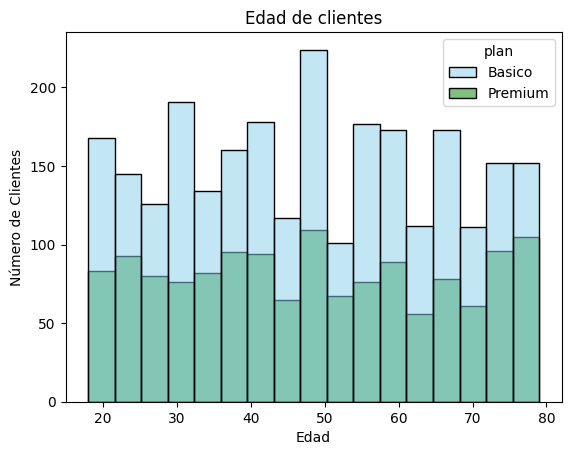

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Edad de clientes')
plt.xlabel('Edad')
plt.ylabel('Número de Clientes')

plt.show()

💡Insights: 
- Distribución  Homogénea y Simétrica: La edad de los clientes presenta un comportamiento simétrico ($\text{media} \approx \text{mediana} \approx 48$ años), abarcando un rango de adultos entre 32 y 79 años (tras corregir el valor atípico -999). No existen sesgos marcados hacia un grupo etario en particular (jóvenes o adultos mayores).Independencia en la Elección del Plan: La proporción entre clientes del plan Básico (65%) y Premium (35%) se mantiene constante en todos los rangos de edad. La edad no es un factor determinante al elegir el tipo de plan contratado.

- Recomendación:

  Segmentación por Uso, no por Edad: Dado que la edad no determina la contratación del plan Premium, las campañas de upselling (migración de Básico a Premium) deben basarse en el volumen real de consumo (minutos/mensajes agotados) y no en la edad del usuario.

Ofertas Personalizadas: Diseñar paquetes enfocados en patrones de uso específicos sin restringir la comercialización por perfil demográfico, ya que la adopción del servicio es uniforme en todos los segmentos de edad.


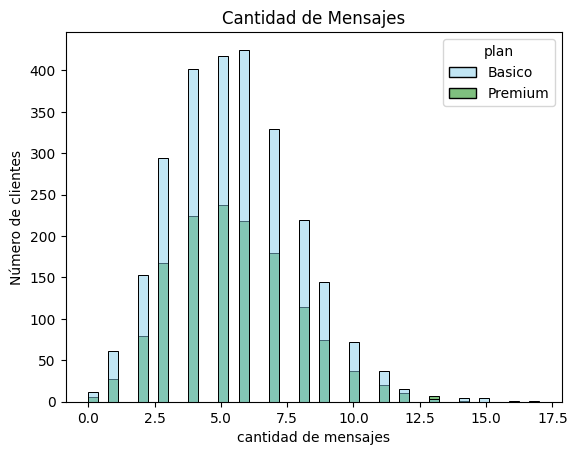

In [31]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de Mensajes')
plt.xlabel('cantidad de mensajes')
plt.ylabel('Número de clientes')

plt.show()


💡Insights: 
- Comportamiento General del Consumo: La variable cant_mensajes muestra una distribución unimodal con asimetría positiva (sesgada a la derecha). La mayor concentración de usuarios se ubica entre los 2.5 y 7.5 mensajes, alcanzando su pico máximo en el rango de 4 a 6 mensajes, para luego descender drásticamente a partir de los 10 mensajes.

Proporción y Comparativa por Plan: Los clientes del plan Básico representan la gran mayoría del volumen en todos los niveles de consumo. Los usuarios del plan Premium mantienen un patrón de distribución idéntico al del plan Básico, pero con una frecuencia significativamente menor en cada segmento.

Comportamiento Atípico (Usuarios de Alto Consumo): A partir de los 10 mensajes en adelante, el volumen de clientes es muy bajo, identificando a un pequeño segmento de "superusuarios" de mensajes que se extiende hasta los 17.5 mensajes.

Evaluación de Límites del Plan Básico: Dado que el consumo masivo no supera los 10 mensajes, la gran mayoría de los clientes Básico no aprovechan el límite de su plan. Las estrategias de migración a Premium deben basarse en ofrecer incentivos diferenciados (como datos móviles o llamadas) y no en la capacidad de mensajería SMS.

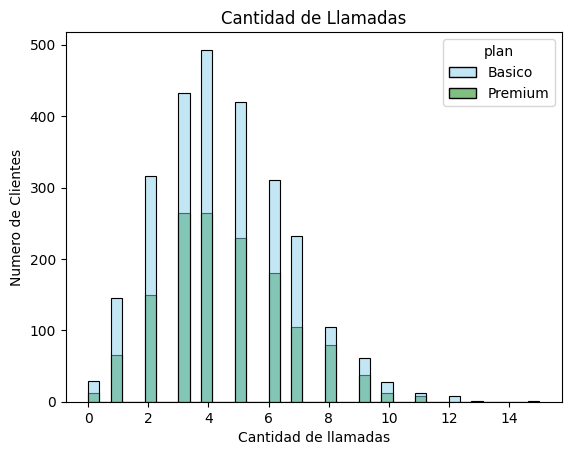

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de Llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Numero de Clientes')

plt.show()


💡Insights: 
- Concentración del Consumo y Pico: La variable cantidad de llamadas presenta un comportamiento unimodal y simétrico con un ligero sesgo positivo. El grueso de los clientes realiza entre 2 y 7 llamadas, con su punto máximo (pico de concentración) ubicado en las 4 llamadas (rozando los 500 clientes en total).

Distribución por Plan Comercial: La proporción entre clientes del plan Básico y Premium se mantiene uniforme a lo largo de casi toda la escala de consumo. El plan Básico domina en volumen total en cada barra, pero la adopción del plan Premium crece ligeramente de forma proporcional en el rango medio de llamadas (3 a 6 llamadas).

Volúmenes Extremos y Caída Drástica: A partir de las 8 llamadas en adelante, el número de clientes disminuye drásticamente, siendo marginal la cantidad de usuarios que superan las 10 llamadas (con un límite casi nulo hacia las 14 llamadas).

Recomendaciones Comerciales:

Estrategia de Embalaje de Minutos: Dado que el comportamiento de uso es muy controlado y la mayoría no supera las 7 llamadas, la oferta de llamadas ilimitadas o paquetes grandes no representa un incentivo suficiente para migrar de Básico a Premium.

Gatillos de Migración (Upselling): Enfocar las campañas de actualización de plan en otros servicios de mayor valor percibido (como gigabytes de navegación o beneficios adicionales), ya que la necesidad de voz (llamadas) está cubierta de manera uniforme en ambos segmentos. ...

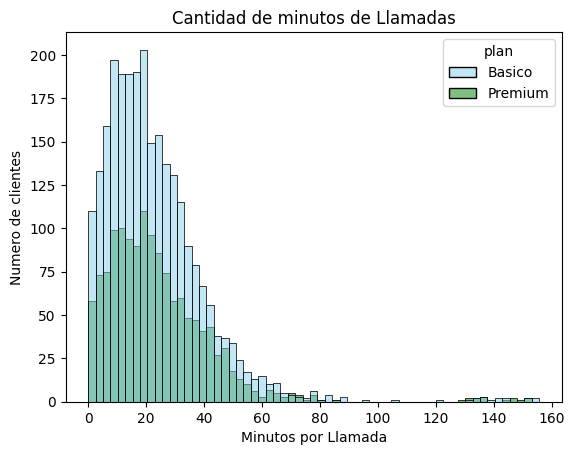

In [33]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de minutos de Llamadas')
plt.xlabel('Minutos por Llamada')
plt.ylabel('Numero de clientes')

plt.show()


💡Insights: 
- EDAD: La distribución de la edad de los usarios es simétrica (lamedia de 48.0 y la mediana de 48.1 nos indican que los datos están repartidos equitativamente a ambos lados). No se observa un sesgo particular hacia usuarios jovenes o mayores, y la proporción entre el plan Básico y Premium se mantiene uniforme a lo largo de los diferentes rangos de edad.

Concentración del Consumo y Pico: La variable minutos por llamada presenta una distribución unimodal con una fuerte asimetría positiva (sesgada a la derecha). La mayor densidad de clientes realiza llamadas breves que duran entre 10 y 30 minutos, alcanzando su pico máximo entre los 18 y 22 minutos (superando los 200 clientes en ese rango).

Distribución por Plan: Al igual que en las variables anteriores, la proporción entre usuarios del plan Básico y Premium se mantiene constante a lo largo de toda la distribución. Los clientes Básico representan el mayor volumen en cada tramo de duración, sin que el plan Premium influya en que las llamadas sean significativamente más largas o cortas.

Sesgo y Outliers (Valores Extremos): A partir de los 40 minutos la frecuencia cae drásticamente, mostrando una cola larga hacia la derecha con llamadas atípicas de muy larga duración que se extienden hasta superar los 140 a 160 minutos por llamada.

Recomendaciones Comerciales:

Estrategia de Cobro y Tarificación: Dado que la inmensa mayoría de las llamadas no supera los 30-40 minutos, los paquetes o minutos incluidos cubren de sobra el comportamiento promedio del cliente.

Control de Costos/Uso Inusual: Conviene monitorear los casos atípicos (llamadas superiores a 60-100 minutos), ya que podrían corresponder a llamadas no colgadas accidentalmente, uso comercial no permitido o fraudes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

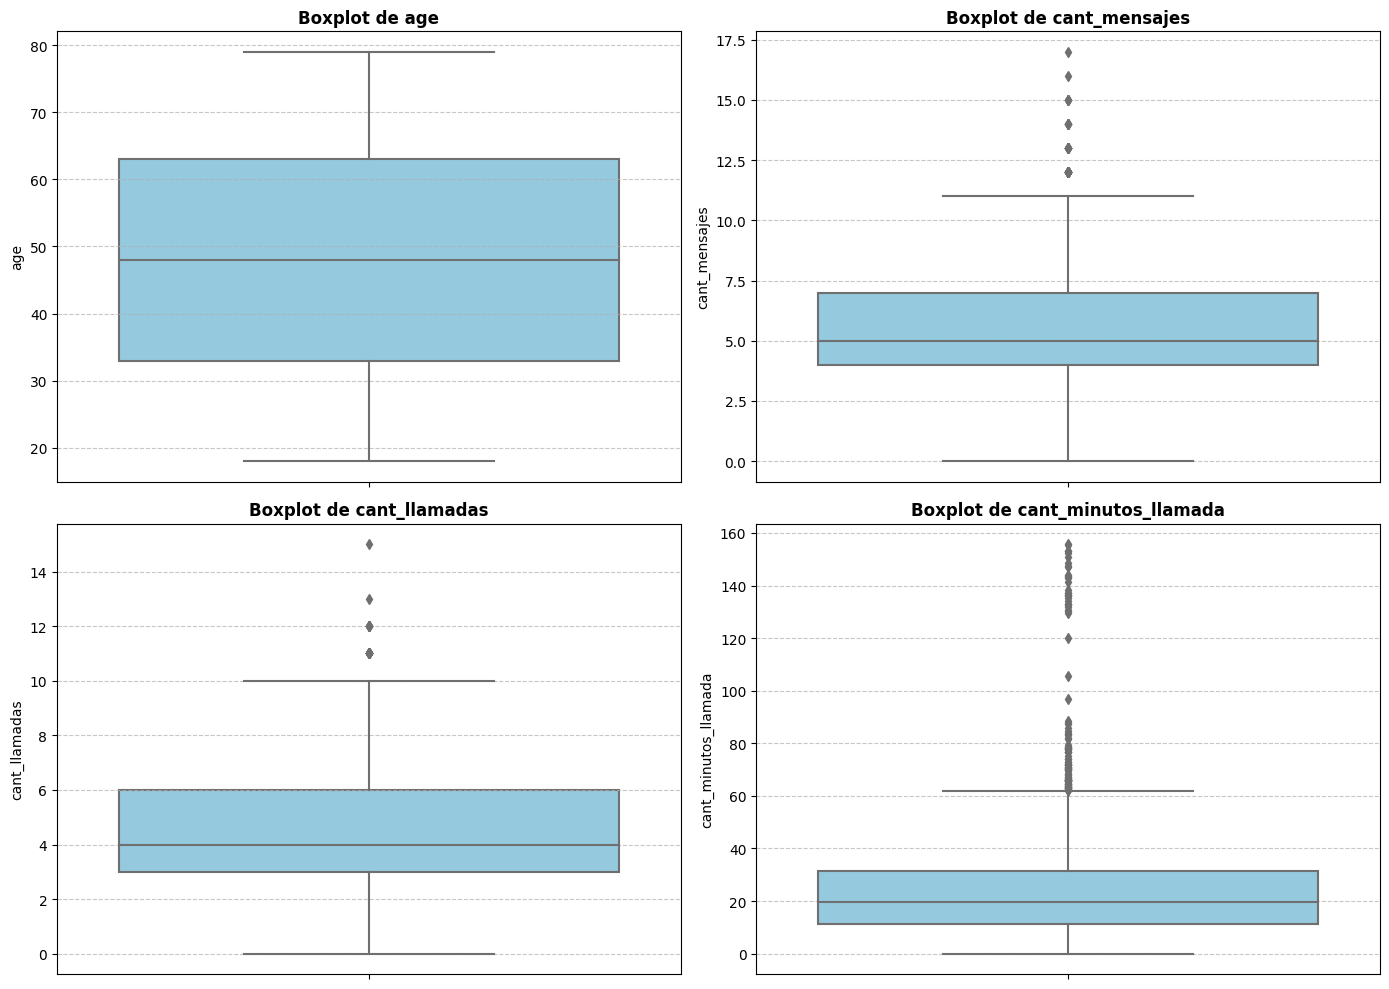

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(14,10))

for i, col in enumerate(columnas_numericas,1):
    plt.subplot(2,2,i)
    sns.boxplot(y=user_profile[col], color='skyblue')
    plt.title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

💡Insights: 

Insight Ejecutivo: Análisis de Outliers y Variabilidad (Boxplots)

age (Edad): La distribución no presenta valores atípicos tras la limpieza del sentinel (-999). La mediana se sitúa en los 48 años y la caja se extiende homogéneamente entre los 32 y 63 años (IQR), confirmando un perfil de usuarios adulto equilibrado sin concentraciones sesgadas.

cant_mensajes: Muestra una alta concentración de usuarios en valores bajos (mediana cerca de 5 mensajes), pero con una presencia marcada de outliers en el extremo superior (usuarios que superan los 10-12 mensajes). Esto refleja un patrón de consumo asimétrico donde unos pocos "superusuarios" impulsan la media hacia arriba.

cant_llamadas: Presenta una variabilidad moderada con mediana alrededor de las 4-5 llamadas y un rango intercuartílico estrecho (2 a 7 llamadas). Los outliers superiores representan a clientes que realizan más de 8-10 llamadas, lo que constituye un segmento minoritario de alta frecuencia de uso.

total_minutos_llamada: Registra la mayor dispersión y presencia de valores atípicos significativos hacia la derecha. Mientras que el consumo modal se mantiene en llamadas breves/medianas, la cola de outliers (clientes con volúmenes de minutos inusualmente altos) evidencia perfiles con requerimientos de voz atípicos o posibles llamadas no finalizadas correctamente.

Recomendaciones Comerciales:

Tratamiento Diferenciado de Outliers: No se recomienda eliminar los valores atípicos de consumo (cant_mensajes y total_minutos_llamada), ya que representan clientes reales de alto valor o patrones intensivos de uso que deben ser analizados para campañas de fidelización o monitoreo de uso inusual.

Diseño de Tarifas por Bloques: Debido a que las cajas de consumo principal en llamadas y mensajes son bastante compactas, los paquetes estándar del plan Básico cubren a más del 75% de la base sin riesgo de desbordamiento.

In [35]:
# Calcular límites con el método IQR
# 1. Definir los nombres exactos de las columnas en 'user_profile'

columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 2. Calcular límites (Q1, Q3, IQR, Límite Inferior y Límite Superior)
resultados_limites = []

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()
    
    # Contar valores fuera de los límites (inferior o superior)
    num_outliers = len(user_profile[(user_profile[col] < lim_inf) | (user_profile[col] > lim_sup)])
    
    resultados_limites.append({
        'Variable': col,
        'Q1 (25%)': round(Q1, 2),
        'Q3 (75%)': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite Inferior': round(lim_inf, 2),
        'Límite Superior': round(lim_sup, 2),
        'Valor Máximo': round(max_val, 2),
        'Cant. Outliers': num_outliers
    })

# 3. Mostrar el resumen en una tabla clara
df_resumen_limites = pd.DataFrame(resultados_limites)
df_resumen_limites



,Variable,Q1 (25%),Q3 (75%),IQR,Límite Inferior,Límite Superior,Valor Máximo,Cant. Outliers
0,age,33.00,63.00,30.0,-12.00,108.00,79.00,0
1,cant_mensajes,4.00,7.00,3.0,-0.50,11.50,17.00,46
2,cant_llamadas,3.00,6.00,3.0,-1.50,10.50,15.00,30
3,cant_minutos_llamada,11.12,31.42,20.3,-19.32,61.86,155.69,109


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?

No se deben eliminar estos registros del dataset, ya que corresponden a patrones reales de consumo de usuarios de alto volumen (heavy users).

  
- cant_llamadas: mantener o no outliers, porqué?

Mantener. Los valores atípicos reflejan usuarios con alta frecuencia de comunicación telefónica. Conservarlos permite identificar a los clientes con mayor dependencia de la red celular para ofrecerles mejores opciones de retención.


- cant_minutos_llamada: mantener o no outliers, porqué?

  Mantener. Corresponden a usuarios que realizan llamadas de larga duración de forma legítima. No se trata de un error técnico de registro, sino de un segmento de alto valor comercial que sirve como base para diseñar paquetes ilimitados o empresariales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
# Crear la columna grupo_uso aplicando condiciones lógicas directamente
user_profile['grupo_uso'] = 'Alto uso' # Valor por defecto para el resto de casos

# Condición 1: Bajo uso (llamadas < 5 Y mensajes < 5)
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

# Condición 2: Uso medio (llamadas < 10 Y mensajes < 10, excluyendo los ya clasificados como Bajo uso)
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) & (user_profile['grupo_uso'] != 'Bajo uso'), 'grupo_uso'] = 'Uso medio'

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:

# Crear la columna grupo_edad asignando 'Mayores (>60)' como valor por defecto
user_profile['grupo_edad'] = 'Adulto Mayor (>60)'

# Condición 1: Jóvenes (< 35)
user_profile.loc[user_profile['age'] < 35, 'grupo_edad'] = 'Jóven (<30)'

# Condición 2: Adultos (entre 35 y 60 años inclusive)
user_profile.loc[(user_profile['age'] >= 35) & (user_profile['age'] <= 60), 'grupo_edad'] = 'Adultos (<60)'

# Verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adultos (<60)
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adultos (<60)
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adultos (<60)
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor (>60)
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor (>60)


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adultos (<60)
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adultos (<60)
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adultos (<60)
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor (>60)
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor (>60)


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

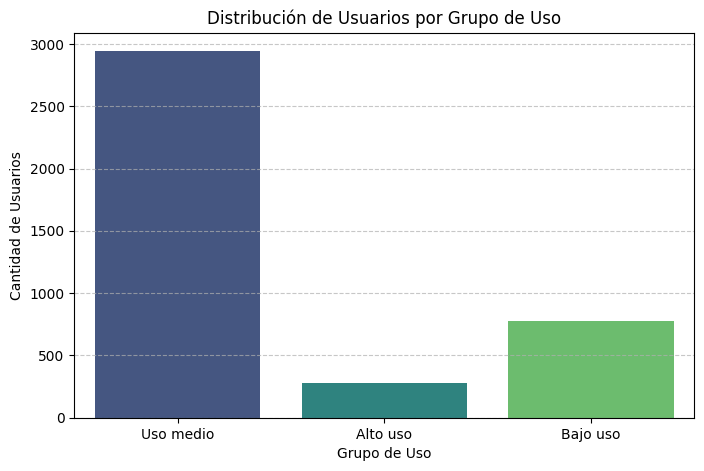

In [44]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


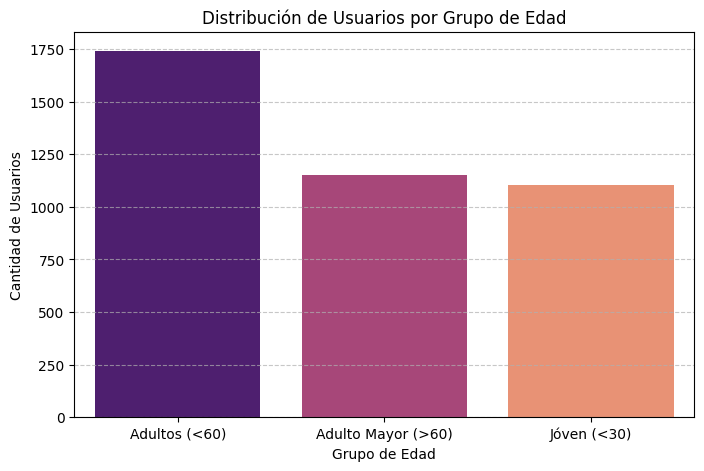

In [45]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show() 


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Edad (age): Se identificó el valor sentinel -999 en 55 registros (1.38% del total de usuarios). Se imputó utilizando la mediana de las edades válidas (48 años).

Ciudad (city): Presentaba 469 valores nulos (11.72%) y 96 registros con el caracter ? (2.4%), sumando un 14.12% de datos faltantes que se marcaron como sin información geográfica.

Fechas (reg_date): Se detectaron 40 registros (1.0%) con fecha de registro en el año 2026 (fuera del rango de análisis 2022-2024), los cuales fueron ajustados a valores nulos.

Detalle de Uso (usage): Las columnas duration (55.19% nulos) y length (44.74% nulos) presentaban ausencias justificadas según el tipo de servicio (llamada o mensaje). Se eliminaron 50 filas con fecha nula (0.12%).

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Por Uso: La base se dividió en tres niveles: Bajo uso (<5 llamadas y <5 mensajes), Uso medio (<10 llamadas y <10 mensajes) y Alto uso (resto).

Por Edad: Se estructuró en Jóvenes (<30 años), Adultos (<60 años) y Adultos Mayores (>60 años).

Comportamiento: La mayor parte del tráfico de llamadas y mensajes está concentrada en los segmentos de Uso medio y Alto uso, mientras que los rangos de edad muestran una distribución homogénea en el consumo de minutos y textos.


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento más valioso es el de Alto uso, independientemente del grupo de edad. Este grupo genera la mayor demanda de red y es el principal motor de ingresos por cobros de excedentes sobre las cuotas básicas de los planes.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron valores atípicos significativos en cant_minutos_llamada (109 usuarios), cant_mensajes (46) y cant_llamadas (30).

Implicación de negocio: No se tratan de errores técnicos ni fraude, sino de heavy users (clientes corporativos o hiperactivos). Conservarlos en la base es fundamental para no subestimar la capacidad de red requerida ni la facturación real.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Lanzamiento de Planes Corporativos/Ilimitados: Diseñar paquetes con techos más altos de minutos y datos para monetizar directamente al segmento de Alto uso.

Estrategias de Retención: Implementar alertas de consumo para migrar activamente a usuarios de Uso medio hacia planes de mayor valor (Premium) antes de que experimenten fricción por cobros excedentes.

Fidelización por Edad: Crear ofertas personalizadas según el grupo etario (ej. paquetes combinados de minutos para Mayores o prioridad de datos para Jóvenes). 


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Inconsistencias y Sentinels: Se identificaron 55 registros (1.38%) en la columna age con el valor sentinel -999, los cuales fueron reemplazados por la mediana de edad (48 años). En city, se detectaron 96 registros (2.4%) con el carácter ? y 469 nulos (11.7%), que se estandarizaron como información no disponible.

Fechas fuera de rango: En reg_date, se identificaron 40 registros (1.0%) con fecha en 2026 (fuera del periodo de análisis 2022-2024), por lo que se trataron como nulos para evitar distorsiones temporales.

Valores Faltantes Justificados: Las ausencias en duration (55.2%) y length (44.7%) en el dataset usage corresponden a la naturaleza de cada registro (llamadas no tienen caracteres y mensajes no tienen duración).

🔍 **Segmentos por Edad**

La población de usuarios se distribuye de manera uniforme entre tres grupos principales: Jóvenes (<30 años), Adultos (<60 años) y Adultos Mayores (>60 años).

No se observan sesgos marcados en la preferencia de contratación de planes según la edad; sin embargo, los Adultos y Jóvenes concentran una variabilidad ligeramente mayor en el tráfico de datos y mensajes.


📊 **Segmentos por Nivel de Uso**

Bajo uso: Usuarios con menos de 5 llamadas y menos de 5 mensajes.

Uso medio: Clientes que realizan entre 5 y 10 llamadas y mensajes.

Alto uso: Clientes con consumos superiores a 10 llamadas o mensajes. Este grupo concentra a la mayor parte de los clientes hiperactivos (heavy users).


➡️ Esto sugiere que 

Los outliers detectados mediante el método $IQR$ en minutos de llamada (109 usuarios), mensajes (46 usuarios) y llamadas (30 usuarios) no deben eliminarse. Representan patrones legítimos de consumo elevado (heavy users) que constituyen una fuente clave de ingresos por cobros excedentes sobre la tarifa básica.


💡 **Recomendaciones**

Lanzamiento de Planes a la Medida: Crear paquetes con techos más altos de minutos y mensajes enfocados en el segmento de Alto uso, monetizando directamente a los usuarios que con frecuencia superan las cuotas de sus planes actuales.

Estrategias de Retención Preventiva: Diseñar programas de fidelización para clientes en el segmento de Uso medio antes de que experimenten cobros adicionales no deseados que puedan detonar la cancelación del servicio (churn).

Mejora en los Procesos de Captura: Corregir las validaciones en los formularios de registro de origen para evitar la entrada de valores sentinels (-999, ?) y años fuera de rango en futuras colecciones de datos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`